In [3]:
import os
import json
import random
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

LABEL_MAP = {
    "normal": 0, "crack": 1, "leak": 2, "efflorescence": 3,
    "detachment": 4, "reticular crack": 5, "spalling": 6,
    "material separation": 7, "rebar": 8, "damage": 9, "exhilaration": 10
}
CLASS_NAMES = list(LABEL_MAP.keys())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [10]:
def prepare_validation_data(base_dir):
    test_data_list = []
    json_paths = list(Path(base_dir).rglob("*.json"))
    
    for json_path in tqdm(json_paths):
        img_path_str = str(json_path).replace('02.라벨링데이터', '01.원천데이터')
        img_path_str = img_path_str.replace('02.라벨링데이터', '01.원천데이터')
        img_path_str = img_path_str.replace('VL_', 'VS_')
        img_path_str = img_path_str.replace('.json', '.jpg')        
        img_path = Path(img_path_str)
        
        if not img_path.exists():
            continue

        with open(json_path, 'r', encoding='utf-8') as f:
            try:
                data = json.load(f)
            except:
                continue
                
            img_info = data.get("image", {})
            is_defect = img_info.get("object_included", "N")
            
            if is_defect == "N":
                test_data_list.append((str(img_path), 0))
            elif is_defect == "Y":
                annotations = img_info.get("annotations", [])
                for ann in annotations:
                    label_str = ann.get("label", "").lower().strip().replace("_", " ")
                    if label_str in LABEL_MAP:
                        test_data_list.append((str(img_path), LABEL_MAP[label_str]))
                        break
    return test_data_list

class CrackDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long), img_path

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_base_dir = r"D:\Study\HumanStudy\Dataset\Validation"
test_list = prepare_validation_data(test_base_dir)
test_dataset = CrackDataset(test_list, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"총 테스트 이미지 수: {len(test_list):,}장")

100%|███████████████████████████████████████████████████████████████████████████| 52500/52500 [04:10<00:00, 209.45it/s]

총 테스트 이미지 수: 52,500장


In [ ]:
model_name = 'mobilenetv3_large_100'
model = timm.create_model(model_name, pretrained=False, num_classes=11)

model.load_state_dict(torch.load('best_mobilenetv3_large_100_multi_label.pth'))
model = model.to(device)
model.eval()

class MaskedBCELoss(nn.Module):
    def __init__(self, pos_weight=1.0, neg_weight=0.3):
        super().__init__()
        self.pos_weight = pos_weight
        self.neg_weight = neg_weight 
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        weight_mask = targets * self.pos_weight + (1 - targets) * self.neg_weight
        return (bce_loss * weight_mask).mean()

criterion = MaskedBCELoss(pos_weight=1.0, neg_weight=0.3)

all_labels = []
all_preds = []
running_loss = 0.0
corrects = 0

with torch.no_grad():
    for images, labels, _ in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        
        labels_one_hot = F.one_hot(labels, num_classes=11).float()
        
        outputs = model(images)
        loss = criterion(outputs, labels_one_hot)
        running_loss += loss.item() * images.size(0)
        
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        
        corrects += (preds * labels_one_hot).sum().item()
        
        all_labels.append(labels_one_hot.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

all_labels = np.vstack(all_labels)
all_preds = np.vstack(all_preds)

test_loss = running_loss / len(test_dataset)
main_acc = corrects / len(test_dataset)

print(f"\n[Test Results]")
print(f"Test Loss: {test_loss:.4f}")
print(f"Main Label Accuracy: {main_acc:.4f} ({main_acc*100:.2f}%)\n")

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))

In [14]:
model_name = 'efficientnet_b0'
model = timm.create_model(model_name, pretrained=False, num_classes=11)

model.load_state_dict(torch.load('best_efficientnet_b0_multi_label.pth'))
model = model.to(device)
model.eval()

C:\Users\SehoonChoi\AppData\Local\Temp\ipykernel_27692\1069090328.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_efficientnet_b0_

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

C:\Users\SehoonChoi\AppData\Local\Temp\ipykernel_27692\570326171.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_bar.legend()


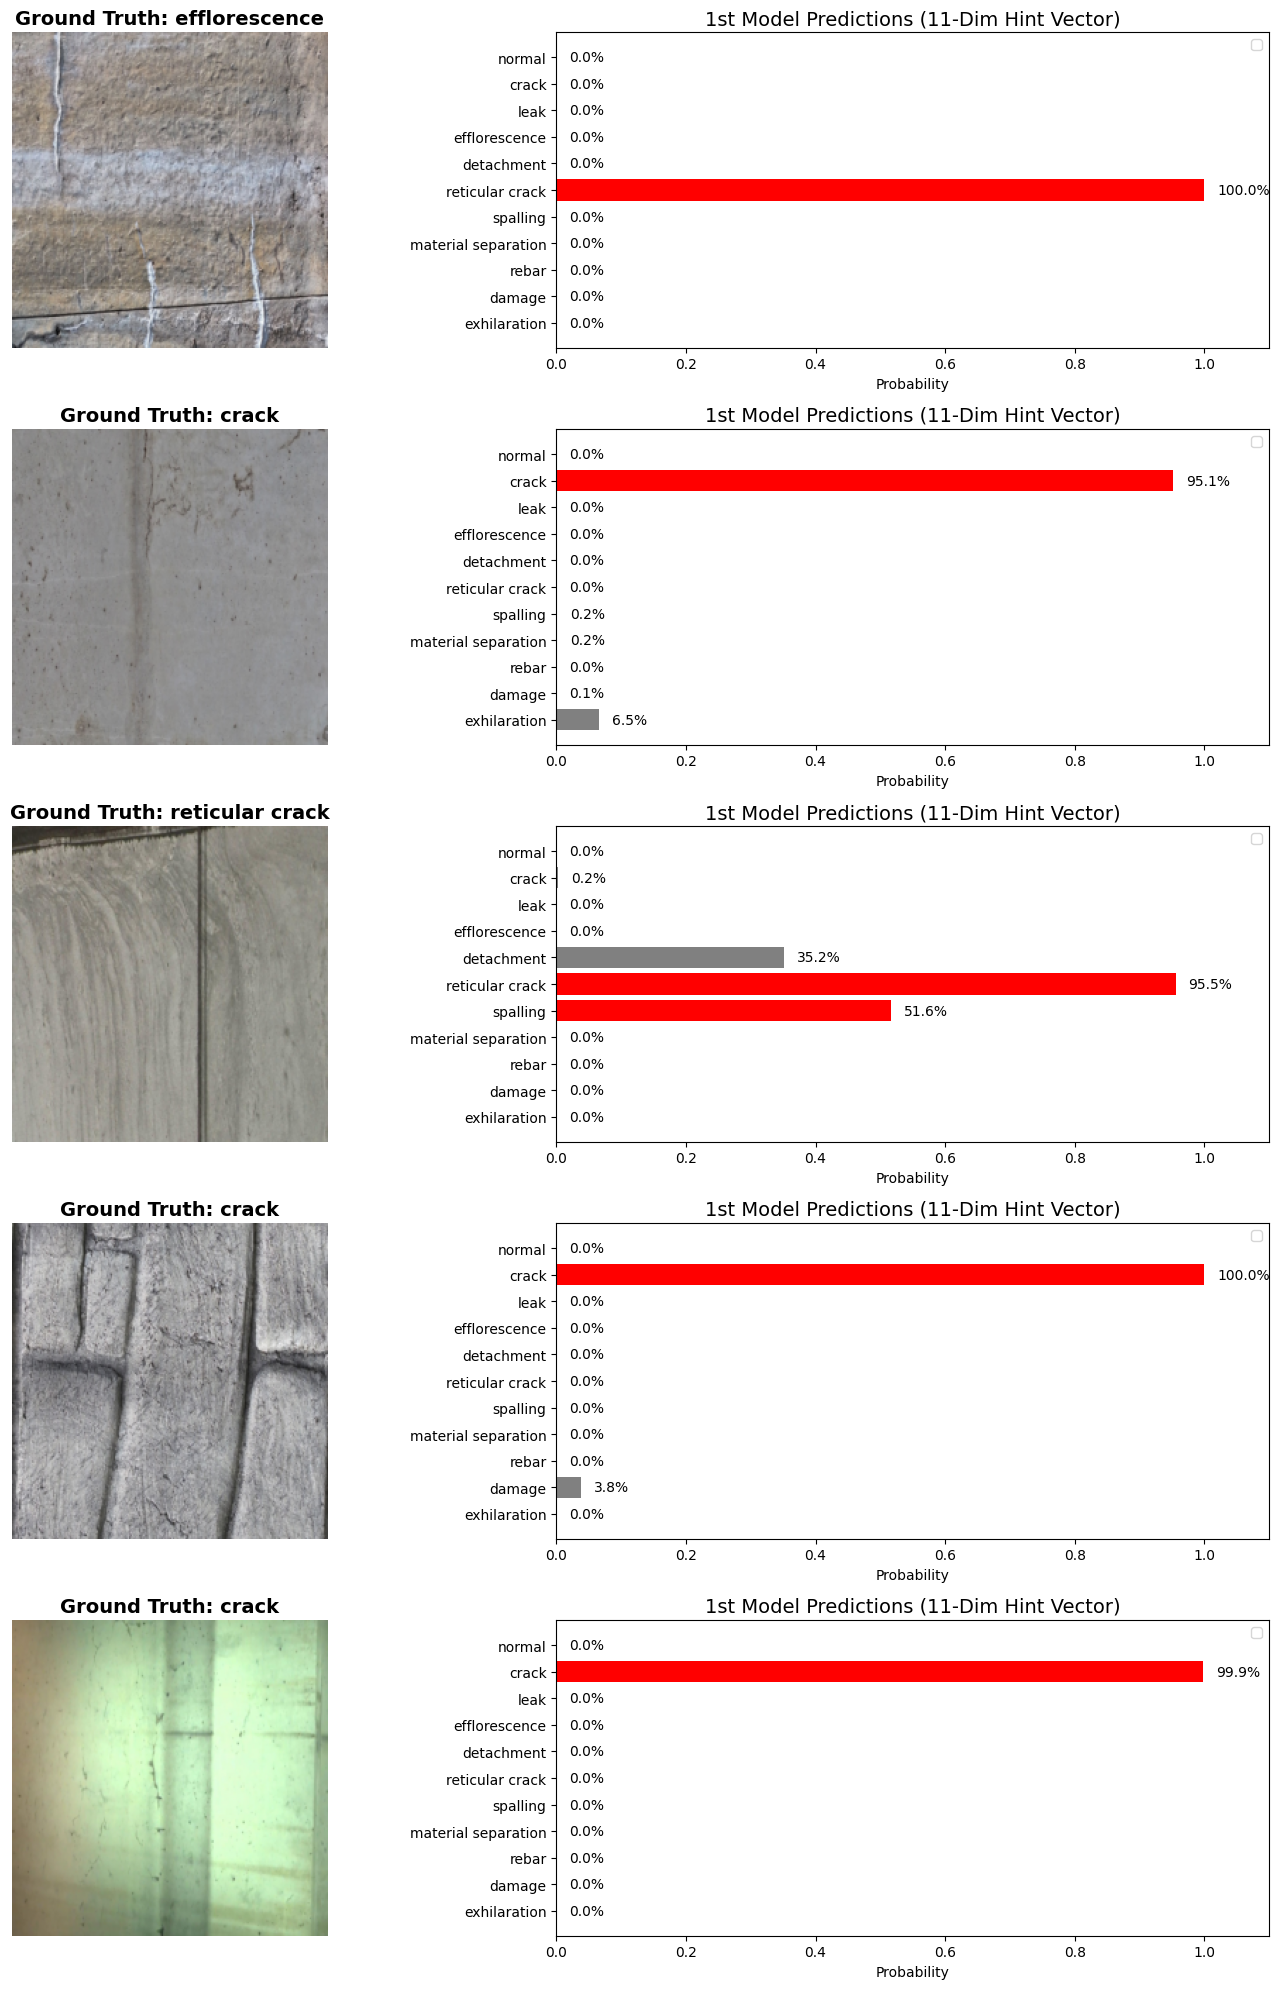

In [28]:
def visualize_random_predictions(dataset, model, num_images=5):
    model.eval()
    
    indices = random.sample(range(len(dataset)), num_images)
    
    fig, axes = plt.subplots(num_images, 2, figsize=(15, 4 * num_images))
    if num_images == 1: axes = [axes]
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image_tensor, label_idx, img_path = dataset[idx]
            true_label_name = CLASS_NAMES[label_idx.item()]
            
            img_input = image_tensor.unsqueeze(0).to(device)
            outputs = model(img_input)
            probs = torch.sigmoid(outputs).squeeze(0).cpu().numpy()
            
            ax_img = axes[i][0]
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img_show = image_tensor.permute(1, 2, 0).numpy()
            img_show = std * img_show + mean
            img_show = np.clip(img_show, 0, 1)
            
            ax_img.imshow(img_show)
            ax_img.set_title(f"Ground Truth: {true_label_name}", fontsize=14, fontweight='bold')
            ax_img.axis('off')
            
            ax_bar = axes[i][1]
            colors = ['gray' if p < 0.5 else 'red' for p in probs]
            bars = ax_bar.barh(CLASS_NAMES, probs, color=colors)
            ax_bar.set_xlim(0, 1.1)
            ax_bar.set_title("1st Model Predictions (11-Dim Hint Vector)", fontsize=14)
            ax_bar.set_xlabel("Probability")
            ax_bar.invert_yaxis() 
            ax_bar.legend()
            
            for bar, p in zip(bars, probs):
                ax_bar.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
                            f"{p*100:.1f}%", va='center', ha='left', fontsize=10)
                
    plt.tight_layout()
    plt.show()

visualize_random_predictions(test_dataset, model, num_images=5)